# Блокнот для изучения метода генерации полей

Цель блокнота - сгенерировать fractional Gaussian noise (fGn) — случайное поле с фрактальной структурой и заданным показателем Хёрста $H$.

### Схема процесса

```
Белый шум (Fourier)
        ↓
Степенной фильтр |k|^{-(H + (d-2)/2)}
        ↓
Обратное FFT
        ↓
fractional Gaussian noise
```

### 1. Белый шум в Фурье-пространстве

Формируем белый гауссов шум:

$
\hat{\xi}(\mathbf{k}) = \xi_1(\mathbf{k}) + i\,\xi_2(\mathbf{k}),
\quad
\xi_1, \xi_2 \sim \mathcal{N}(0,1)
$

Свойство белого шума:

$
\mathbb{E}|\hat{\xi}(\mathbf{k})|^2 = \text{const}
$


### 2. Пространство волновых чисел

Каждой частоте Фурье соответствует вектор:

$
\mathbf{k} = (k_1, \dots, k_d)
$

и его длина:

$
|\mathbf{k}| = \sqrt{k_1^2 + \dots + k_d^2}
$


### 3. Степенной спектр fGn

Для fractional Gaussian noise в размерности $d$ спектральная плотность мощности имеет вид:

$
P_{\text{fGn}}(\mathbf{k})
\;\propto\;
|\mathbf{k}|^{-(2H + d - 2)}
$

где:

* $H \in (0,1)$ — показатель Хёрста
* $d$ — размерность пространства

Это на 2 меньше в показателе по сравнению с fBm ($|\mathbf{k}|^{-(2H+d)}$), что соответствует переходу от интегрального процесса к его приращениям.


### 4. Амплитудный фильтр

Так как умножается амплитуда, а не мощность, используется корень:

$
S(\mathbf{k}) \;\propto\;
|\mathbf{k}|^{-(H + (d-2)/2)}
$

И формируем сигнал — окрашенный белый шум:

$
\hat{u}(\mathbf{k}) = S(\mathbf{k}) \cdot \hat{\xi}(\mathbf{k})
$

### 5. Нулевая частота

В точке $\mathbf{k} = 0$:

$
|\mathbf{k}|^{-(H + (d-2)/2)} \to \infty \quad (d \geq 1,\; H > 0)
$

Поэтому мы принудительно задаём: $\hat{u}(0) = 0$, чтобы устранить расходимость.


### 6. Обратное преобразование Фурье

Теперь выполняем обратное преобразование Фурье:

$
u(\mathbf{x}) =
\mathcal{F}^{-1}
\left[
\hat{\xi}(\mathbf{k})\,|\mathbf{k}|^{-(H + (d-2)/2)}
\right]
$

Результатом будет **fractional Gaussian noise** — статционарное поле с заданным $H$.


### Anisotropic fGn
Для генерации поля, у которого разный Hurst по осям — anisotropic fGn — пункты 2–5 изменены.

Anisotropic fGn:

$
\mathbb{E}|X(x + h\,e_i) - X(x)|^2 \sim |h|^{2H_i}
$

* по оси $x$ — $H_x$,
* по $y$ — $H_y$,
* по $z$ — $H_z$.

Для анизотропного fGn используется сепарабельный спектр:

$
S(\mathbf{k}) \propto \prod_{i=1}^{d} |k_i|^{-(H_i - 1/2)}
$

### **Источники**:

* Timmer, J., & Koenig, M. (1995),
  *On generating power law noise*. Astronomy and Astrophysics, v. 300, p. 707, 300, 707.

* Dietrich & Newsam (1997),
  *Fast and Exact Simulation of Stationary Gaussian Processes through Circulant Embedding of the Covariance Matrix*
  [https://doi.org/10.1137/S1064827592240555](https://doi.org/10.1137/S1064827592240555)

* Mandelbrot & Van Ness (1968),
  *Fractional Brownian motions, fractional noises and applications*
  [https://doi.org/10.1137/1010093](https://doi.org/10.1137/1010093)

### Нормировка

Чаще всего поле масштабируют, это обеспечивает универсальность метода в экспериментах. Для этого в функции `ndfnoise` есть параметр `normalize`, который по умолчанию имеет значение `True`.

$
X_H(x) \leftarrow \frac{X_H(x) - \mathbb{E}[X_H]}{\sqrt{\mathrm{Var}(X_H)}}.
$

# 3. Пример использования

В следующих разделах используется метод для одинакового Hurst по всем осям, это изотропный случай, когда одинаковая шероховатость во всех направлениях.

In [1]:
import multiprocessing
from typing import Union

import numpy as np
from matplotlib import pyplot as plt

from StatTools.generators.ndfnoise_generator import ndfnoise
from StatTools.analysis import analyse_zero_cross_ff
from StatTools.analysis.dfa import dfa

In [2]:
%%time
f2 = ndfnoise((2**9, 2**9, 2**9), hurst=1)

CPU times: user 2.9 s, sys: 713 ms, total: 3.61 s
Wall time: 4.05 s


In [3]:
def _process_2d_slice(slice_2d: np.ndarray) -> float:
    """
    Calculate DFA for slice.
    """
    s_vals, f2_vals = dfa(slice_2d, degree=2, processes=1)
    hs = np.sqrt(f2_vals)
    ff_parameters, _ = analyse_zero_cross_ff(hs, s_vals)
    return ff_parameters.slopes[0].value


def get_h_dfa_sliced(arr: np.ndarray) -> Union[float, np.ndarray]:
    """
    Calculate DFA for z slices.
    For 2D: single Hurst exponent.
    For 3D: array of Hurst exponents for each 100th slice.
    """
    if len(arr.shape) == 2:
        return _process_2d_slice(arr)
    nz = arr.shape[2]
    slice_indices = np.arange(0, nz, 100)

    with multiprocessing.get_context("fork").Pool(processes=8) as pool:
        slices = [arr[:, :, i] for i in slice_indices]
        results = pool.map(_process_2d_slice, slices)

    return np.array(results)

## 2d field

In [4]:
size = 2**10
for h in [0.5, 0.75, 1.0, 1.25, 1.5]:
    f = ndfnoise((size, size), hurst=h)
    res = get_h_dfa_sliced(f)
    print(f"Ht={h}, Hf Mean +- Std: {np.mean(res):.2f} +- {np.std(res):.2f}")
print(f"Field shape is {f.shape}")

Ht=0.5, Hf Mean +- Std: 0.73 +- 0.00
Ht=0.75, Hf Mean +- Std: 0.88 +- 0.00
Ht=1.0, Hf Mean +- Std: 1.08 +- 0.00
Ht=1.25, Hf Mean +- Std: 1.29 +- 0.00
Ht=1.5, Hf Mean +- Std: 1.53 +- 0.00
Field shape is (1024, 1024)


### Visualization

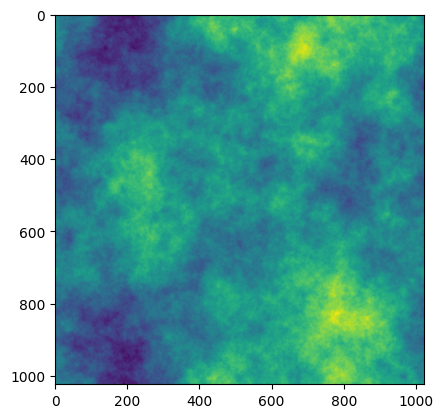

In [5]:
plt.imshow(f)
plt.show()

## 3d field

In [6]:
# Note: Only 10 first slices are calculated in `dfa_sliced` for speed up.
size = 2**9
for h in [0.5, 0.75, 1.0, 1.25, 1.5]:
    f = ndfnoise((size, size, size), hurst=h)
    res = get_h_dfa_sliced(f)
    print(f"Ht={h}, Hf Mean +- Std: {np.mean(res):.2f} +- {np.std(res):.2f}")
print(f"Field shape is {f.shape}")

Ht=0.5, Hf Mean +- Std: 0.81 +- 0.00
Ht=0.75, Hf Mean +- Std: 0.94 +- 0.00
Ht=1.0, Hf Mean +- Std: 1.11 +- 0.00
Ht=1.25, Hf Mean +- Std: 1.31 +- 0.01
Ht=1.5, Hf Mean +- Std: 1.52 +- 0.01
Field shape is (512, 512, 512)


### Visualization

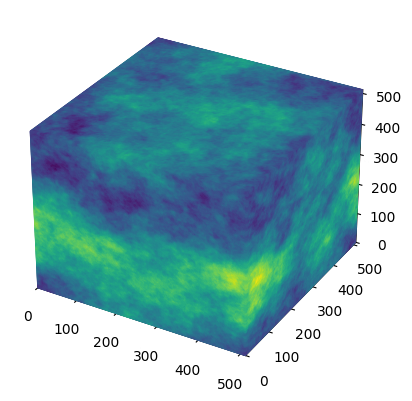

In [7]:
Nx, Ny, Nz = f.shape
stride = max(1, Nx // 256)

f_norm = (f - f.min()) / (f.max() - f.min())

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

Y, Z = np.meshgrid(np.arange(Ny), np.arange(Nz), indexing="ij")
ax.plot_surface(
    np.full_like(Y, Nx - 1), Y, Z,
    facecolors=plt.cm.viridis(f_norm[-1, :, :]),
    rstride=stride, cstride=stride, shade=False,
)

X, Z = np.meshgrid(np.arange(Nx), np.arange(Nz), indexing="ij")
ax.plot_surface(
    X, np.zeros_like(X), Z,
    facecolors=plt.cm.viridis(f_norm[:, 0, :]),
    rstride=stride, cstride=stride, shade=False,
)

X, Y = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing="ij")
ax.plot_surface(
    X, Y, np.zeros_like(Y) + f_norm.shape[2],
    facecolors=plt.cm.viridis(f_norm[:, :, 0]),
    rstride=stride, cstride=stride, shade=False,
)

ax.set_xlim(0, Nx)
ax.set_ylim(0, Ny)
ax.set_zlim(0, Nz)
plt.show()

## Different H

В этом разделе показана генерация поля, у которого разный Hurst по осям — anisotropic fGn.

In [9]:
size = 2**10
h_list = [0.55, 0.75, 1.0, 1.25, 1.5]
for i, h in enumerate(h_list):
    if i == 3:
        break
    f = ndfnoise((size, size), hurst=(h, h_list[-i - 1]))
    resx = get_h_dfa_sliced(f.T)
    resy = get_h_dfa_sliced(f)
    print(f"Ht={h}, Hx Mean +- Std: {np.mean(resx):.2f} +- {np.std(resx):.2f}")
    print(
        f"Ht={h_list[-i - 1]}, Hy Mean +- Std: {np.mean(resy):.2f} +- {np.std(resy):.2f}"
    )
print(f"Field shape is {f.shape}")

Ht=0.55, Hx Mean +- Std: 0.58 +- 0.00
Ht=1.5, Hy Mean +- Std: 1.51 +- 0.00
Ht=0.75, Hx Mean +- Std: 0.74 +- 0.00
Ht=1.25, Hy Mean +- Std: 1.26 +- 0.00
Ht=1.0, Hx Mean +- Std: 1.02 +- 0.00
Ht=1.0, Hy Mean +- Std: 1.01 +- 0.00
Field shape is (1024, 1024)


### Visualization

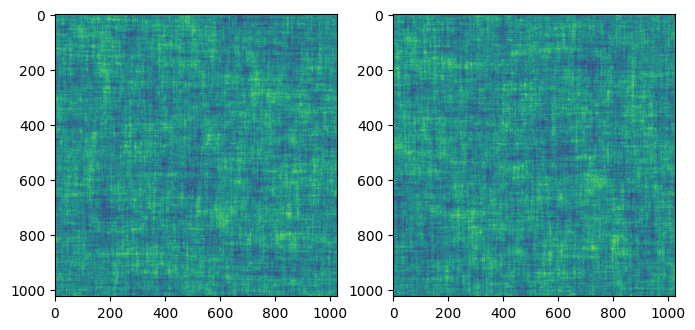

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(f)
ax[1].imshow(f.T)
plt.show()